# 7.0 AirSim 场景数据采集与 VLN 闭环验证

本 Notebook 将前面课程中的 AirSim 场景与第 7 章的 VLN（视觉语言导航）流程打通，实现完整闭环：

```
第3章 视觉感知 ──→ 场景理解 + 目标检测
第4章 Agent框架 ──→ 工具调用 + 自主导航
      ↓                    ↓
第7章 VLN ──→ 数据采集 → 微调 → 推理 → 在AirSim中执行
```

**本节内容：**
1. 用第4章的工具（look、detect、fly_to）在 AirSim 中设计导航任务
2. 自动采集 VLN 训练数据（FPV图像 + 语言指令 + 动作），格式兼容 UAV-Flow
3. 用第3章的视觉模型辅助标注（自动生成语言指令）
4. 微调后的模型回到 AirSim 做在线推理验证

## 0.1 环境准备

复用第4章的 `airsim_smol_wrapper.py` 中的工具函数，同时准备数据采集功能。

In [1]:
import sys
sys.path.append('../external-libraries')
sys.path.append('../airsim_v2')
sys.path.append('../4-agent_app')  # 复用第4章的工具

import airsim
import numpy as np
import cv2
import json
import math
import time
import os
from pathlib import Path
from PIL import Image
from datetime import datetime
import matplotlib.pyplot as plt
from openai import OpenAI

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

# 数据保存路径
OUTPUT_DIR = Path("airsim_vln_data")
OUTPUT_DIR.mkdir(exist_ok=True)

# 图像采集分辨率（与 UAV-Flow / OpenVLA 一致）
IMG_SIZE = 224

# AirSim 连接
client = airsim.MultirotorClient()
client.confirmConnection()
client.enableApiControl(True)
client.armDisarm(True)

# 复用第3章的视觉大模型（用于自动生成指令）
api_key = ""  # 火山方舟 API Key
llm_client = OpenAI(
    api_key=api_key,
    base_url="https://ark.cn-beijing.volces.com/api/v3",
)

print(f"数据保存目录: {OUTPUT_DIR.absolute()}")
print(f"AirSim 已连接")

Connected!
Client Ver:1 (Min Req: 1), Server Ver:1 (Min Req: 1)

数据保存目录: /home/gpx/airgpt_agent/7-done-VLN/airsim_vln_data
AirSim 已连接


## 0.2 工具函数

这些函数整合了前面章节的核心能力：
- **第1章**：AirSim 基础控制（起飞、飞行、位姿获取）
- **第3章**：视觉大模型（场景理解、目标识别）
- **第4章**：深度感知（距离估算）

In [2]:
import base64

def get_pose():
    """获取无人机 6-DoF 位姿 [x, y, z, roll, pitch, yaw]（第1章）"""
    pose = client.simGetVehiclePose()
    pos = pose.position
    orient = pose.orientation
    pitch, roll, yaw = airsim.to_eularian_angles(orient)
    return [
        pos.x_val, pos.y_val, pos.z_val,
        math.degrees(roll), math.degrees(pitch), math.degrees(yaw)
    ]

def capture_fpv(save_path=None, img_size=IMG_SIZE):
    """采集前置摄像头 FPV 图像，缩放到 224x224（第1章 + 第3章）"""
    response = client.simGetImage('0', airsim.ImageType.Scene, vehicle_name='')
    if not response:
        return None
    img = cv2.imdecode(np.array(bytearray(response), dtype='uint8'), cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    if img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
    img = cv2.resize(img, (img_size, img_size))
    if save_path:
        cv2.imwrite(str(save_path), img)
    return img

def describe_scene(img):
    """用第3章的视觉大模型描述当前场景，自动生成导航指令"""
    _, buffer = cv2.imencode('.jpg', img)
    b64 = base64.b64encode(buffer.tobytes()).decode('utf-8')
    
    response = llm_client.chat.completions.create(
        model="doubao-1-5-vision-pro-32k-250115",
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": 
                 "You are helping generate navigation instructions for a drone. "
                 "Look at this first-person view image and generate ONE short English navigation instruction "
                 "(e.g., 'fly toward the building on the left', 'go around the tree ahead', "
                 "'turn right and fly along the road'). Only output the instruction, nothing else."},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
            ],
        }],
        temperature=0.7,
    )
    return response.choices[0].message.content.strip().strip('"').strip("'")

def compute_relative_actions(raw_logs):
    """
    计算帧间相对动作，与 UAV-Flow 的 preprocessed_logs 格式一致。
    输入: raw_logs = [[x, y, z, roll, pitch, yaw, timestamp], ...]
    输出: preprocessed_logs = [[dx, dy, dz, d_roll, d_pitch, d_yaw], ...]
    """
    preprocessed = []
    for i in range(len(raw_logs) - 1):
        curr, next_ = raw_logs[i], raw_logs[i + 1]
        dx_g = next_[0] - curr[0]
        dy_g = next_[1] - curr[1]
        dz = next_[2] - curr[2]
        yaw_rad = math.radians(curr[5])
        dx = dx_g * math.cos(yaw_rad) + dy_g * math.sin(yaw_rad)
        dy = -dx_g * math.sin(yaw_rad) + dy_g * math.cos(yaw_rad)
        d_roll = next_[3] - curr[3]
        d_pitch = next_[4] - curr[4]
        d_yaw = next_[5] - curr[5]
        if d_yaw > 180: d_yaw -= 360
        elif d_yaw < -180: d_yaw += 360
        preprocessed.append([dx, dy, dz, d_roll, d_pitch, d_yaw])
    if preprocessed:
        preprocessed.append(preprocessed[-1])
    return preprocessed

print("工具函数已就绪")

工具函数已就绪


## 0.3 设计导航任务

和第4章的 Agent 任务类似，我们定义无人机要完成的导航任务。

两种模式：
- **手动模式**：自己指定航点和指令（精确控制）
- **自动模式**：让无人机先看一看（第3章 look），视觉大模型自动生成指令

In [3]:
# ============ 手动模式：自定义航点和指令 ============
# 根据你的 AirSim 场景修改航点坐标（NED 坐标系，Z 负数 = 向上）
#
# 场景物体参考（来自第3章/第4章的 objects_dict）：
#   可乐(cola), 兰花(orchid), 椰子水, 小鸭子(duck), 镜子(mirror), 方桌

MANUAL_TASKS = [
    {
        "instruction": "Fly forward along the road",
        "waypoints": [[5, 0, -2], [10, 0, -2], [15, 0, -2], [20, 0, -2]],
        "speed": 2.0,
    },
    {
        "instruction": "Turn left and fly toward the building",
        "waypoints": [[5, 0, -2], [8, -3, -2], [10, -8, -2], [10, -12, -2]],
        "speed": 2.0,
    },
    {
        "instruction": "Turn right and go around the house",
        "waypoints": [[5, 0, -2], [8, 3, -2], [10, 8, -3], [8, 12, -3], [5, 12, -2]],
        "speed": 1.5,
    },
    {
        "instruction": "Fly up high and then move forward",
        "waypoints": [[0, 0, -5], [0, 0, -8], [5, 0, -8], [10, 0, -8]],
        "speed": 2.0,
    },
]

print(f"手动任务 {len(MANUAL_TASKS)} 条:")
for i, t in enumerate(MANUAL_TASKS):
    print(f"  [{i}] {t['instruction']}  ({len(t['waypoints'])} 航点)")

手动任务 4 条:
  [0] Fly forward along the road  (4 航点)
  [1] Turn left and fly toward the building  (4 航点)
  [2] Turn right and go around the house  (5 航点)
  [3] Fly up high and then move forward  (4 航点)


In [4]:
# ============ 自动模式：视觉大模型生成指令 ============
# 无人机先起飞环顾四周，视觉模型看到什么就生成什么样的导航指令
# 这是第3章（视觉感知）和第7章（VLN）的结合

def generate_auto_tasks(n_tasks=4, base_radius=10, height=-3):
    """让无人机转向不同方向，用视觉模型自动生成导航指令和航点"""
    client.reset()
    time.sleep(1)
    client.enableApiControl(True)
    client.armDisarm(True)
    client.takeoffAsync().join()
    client.moveToZAsync(height, 2).join()
    time.sleep(1)

    auto_tasks = []
    angles = np.linspace(0, 360, n_tasks, endpoint=False)

    for angle in angles:
        # 转向指定角度
        client.rotateToYawAsync(angle, 5).join()
        time.sleep(0.5)

        # 拍照 + 视觉模型生成指令
        img = capture_fpv()
        if img is None:
            continue
        instruction = describe_scene(img)
        print(f"  方向 {angle:.0f}°: {instruction}")

        # 根据朝向生成航点（沿当前方向直飞）
        yaw_rad = math.radians(angle)
        waypoints = []
        for dist in [3, 6, 10, base_radius]:
            x = dist * math.cos(yaw_rad)
            y = dist * math.sin(yaw_rad)
            waypoints.append([round(x, 1), round(y, 1), height])

        auto_tasks.append({
            "instruction": instruction,
            "waypoints": waypoints,
            "speed": 2.0,
            "source_angle": angle,
        })

    client.landAsync().join()
    return auto_tasks

print("自动任务生成函数已定义")
print("运行下面的 cell 来自动生成任务（需要 AirSim 仿真器运行中）")

自动任务生成函数已定义
运行下面的 cell 来自动生成任务（需要 AirSim 仿真器运行中）


In [5]:
# 运行自动生成（取消注释执行）
# auto_tasks = generate_auto_tasks(n_tasks=4)
# print(f"\n自动生成 {len(auto_tasks)} 条任务")

# 合并手动和自动任务
# ALL_TASKS = MANUAL_TASKS + auto_tasks

# 目前先用手动任务
ALL_TASKS = MANUAL_TASKS
print(f"总任务数: {len(ALL_TASKS)}")

总任务数: 4


## 0.4 数据采集

核心采集逻辑（整合第1章的飞行控制 + 第3章的图像采集）：
1. 无人机起飞到初始位置
2. 沿航点飞行，**边飞边采集** FPV 图像 + 6-DoF 位姿
3. 计算帧间相对动作
4. 保存为 UAV-Flow 格式（供 7-3 微调使用）

In [6]:
def collect_trajectory(task, traj_id, capture_interval=0.2):
    """
    执行一条导航任务并采集 VLN 数据。
    
    数据格式与 UAV-Flow 完全一致，可直接用于 7-3 的 OpenVLA 微调。
    """
    traj_name = f"traj_{traj_id:03d}"
    traj_dir = OUTPUT_DIR / traj_name
    traj_dir.mkdir(exist_ok=True)
    
    instruction = task["instruction"]
    waypoints = task["waypoints"]
    speed = task["speed"]
    
    print(f"\n{'='*60}")
    print(f"采集轨迹 [{traj_name}]: {instruction}")
    print(f"航点数: {len(waypoints)}, 速度: {speed} m/s")
    
    # 重置并等待无人机完全静止
    client.reset()
    time.sleep(3)  # reset 后多等几秒让物理引擎稳定
    client.enableApiControl(True)
    client.armDisarm(True)
    time.sleep(1)
    
    # 确认速度归零再起飞
    state = client.getMultirotorState()
    v = state.kinematics_estimated.linear_velocity
    speed_now = math.sqrt(v.x_val**2 + v.y_val**2 + v.z_val**2)
    print(f"  Reset后速度: {speed_now:.2f} m/s")
    
    client.takeoffAsync().join()
    time.sleep(0.5)
    
    raw_logs = []
    frame_idx = 0
    
    # 逐航点飞行并采集
    for wp_idx, wp in enumerate(waypoints):
        print(f"  飞往航点 {wp_idx}: {wp}")
        # 用 join() 等到达航点，同时在等待过程中采集数据
        future = client.moveToPositionAsync(wp[0], wp[1], wp[2], speed)
        
        # 边飞边采集
        while not future._set_flag if hasattr(future, '_set_flag') else True:
            img_path = traj_dir / f"{frame_idx:06d}.jpg"
            if capture_fpv(img_path) is not None:
                pose = get_pose()
                pose.append(time.time())
                raw_logs.append(pose)
                frame_idx += 1
            
            # 检查是否到达
            curr_pos = get_pose()[:3]
            dist = math.sqrt(sum((a - b) ** 2 for a, b in zip(curr_pos, wp)))
            if dist < 0.5:
                break
            time.sleep(capture_interval)
        
        # 确保到达航点
        future.join()
    
    # 悬停稳定一下
    client.hoverAsync().join()
    time.sleep(0.5)
    
    # 计算相对动作（与 UAV-Flow 一致）
    preprocessed = compute_relative_actions(raw_logs)
    
    # 保存 log.json
    log_data = {
        "id": traj_name,
        "instruction": instruction,
        "length": frame_idx,
        "raw_logs": [[float(v) for v in row] for row in raw_logs],
        "preprocessed_logs": [[float(v) for v in row] for row in preprocessed],
        "source": "airsim",
        "timestamp": datetime.now().isoformat(),
    }
    with open(traj_dir / "log.json", "w") as f:
        json.dump(log_data, f, indent=2)
    
    # 降落并等待完全停止
    client.landAsync().join()
    time.sleep(1)
    
    print(f"  完成! 帧数: {frame_idx}")
    return log_data

print("采集函数已定义")

采集函数已定义


In [7]:
# 执行采集
all_logs = []
for i, task in enumerate(ALL_TASKS):
    log = collect_trajectory(task, traj_id=i+1)
    all_logs.append(log)
    time.sleep(2)

print(f"\n{'='*60}")
print(f"全部采集完成! 共 {len(all_logs)} 条轨迹")
print(f"数据目录: {OUTPUT_DIR.absolute()}")


采集轨迹 [traj_001]: Fly forward along the road
航点数: 4, 速度: 2.0 m/s
  Reset后速度: 0.00 m/s
  飞往航点 0: [5, 0, -2]
  飞往航点 1: [10, 0, -2]
  飞往航点 2: [15, 0, -2]
  飞往航点 3: [20, 0, -2]
  完成! 帧数: 47

采集轨迹 [traj_002]: Turn left and fly toward the building
航点数: 4, 速度: 2.0 m/s
  Reset后速度: 0.00 m/s
  飞往航点 0: [5, 0, -2]
  飞往航点 1: [8, -3, -2]
  飞往航点 2: [10, -8, -2]
  飞往航点 3: [10, -12, -2]
  完成! 帧数: 46

采集轨迹 [traj_003]: Turn right and go around the house
航点数: 5, 速度: 1.5 m/s
  Reset后速度: 0.00 m/s
  飞往航点 0: [5, 0, -2]
  飞往航点 1: [8, 3, -2]
  飞往航点 2: [10, 8, -3]
  飞往航点 3: [8, 12, -3]
  飞往航点 4: [5, 12, -2]
  完成! 帧数: 73

采集轨迹 [traj_004]: Fly up high and then move forward
航点数: 4, 速度: 2.0 m/s
  Reset后速度: 0.00 m/s
  飞往航点 0: [0, 0, -5]
  飞往航点 1: [0, 0, -8]
  飞往航点 2: [5, 0, -8]
  飞往航点 3: [10, 0, -8]
  完成! 帧数: 45

全部采集完成! 共 4 条轨迹
数据目录: /home/gpx/airgpt_agent/7-done-VLN/airsim_vln_data


## 0.5 数据验证与可视化

验证格式是否和 7-1 中探索的 UAV-Flow 一致。

In [8]:
# 格式验证（对标 7-1 的数据结构）
print("数据格式验证（对标 UAV-Flow）:")
print("=" * 50)

for traj_dir in sorted(OUTPUT_DIR.iterdir()):
    if not traj_dir.is_dir():
        continue
    log_path = traj_dir / "log.json"
    if not log_path.exists():
        continue
    with open(log_path) as f:
        log = json.load(f)
    
    n_img = len(list(traj_dir.glob("*.jpg")))
    n_raw = len(log["raw_logs"])
    n_pre = len(log["preprocessed_logs"])
    raw_d = len(log["raw_logs"][0]) if log["raw_logs"] else 0
    pre_d = len(log["preprocessed_logs"][0]) if log["preprocessed_logs"] else 0
    
    ok = n_img == n_raw == n_pre and raw_d == 7 and pre_d == 6
    print(f"  [{'OK' if ok else 'WARN'}] {log['id']}: \"{log['instruction'][:40]}...\"")
    print(f"       图像={n_img}, raw_logs={n_raw}x{raw_d}, preprocessed={n_pre}x{pre_d}")

数据格式验证（对标 UAV-Flow）:
  [WARN] traj_001: "Fly forward along the road..."
       图像=50, raw_logs=47x7, preprocessed=47x6
  [WARN] traj_002: "Turn left and fly toward the building..."
       图像=47, raw_logs=46x7, preprocessed=46x6
  [WARN] traj_003: "Turn right and go around the house..."
       图像=77, raw_logs=73x7, preprocessed=73x6
  [WARN] traj_004: "Fly up high and then move forward..."
       图像=48, raw_logs=45x7, preprocessed=45x6


<ipython-input-9-4021b0ce45cc>:33: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-9-4021b0ce45cc>:33: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-9-4021b0ce45cc>:33: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-9-4021b0ce45cc>:33: UserWarning: Glyph 20196 (\N{CJK UNIFIED IDEOGRAPH-4EE4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/miniconda3/envs/airsim_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/airsim_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu 

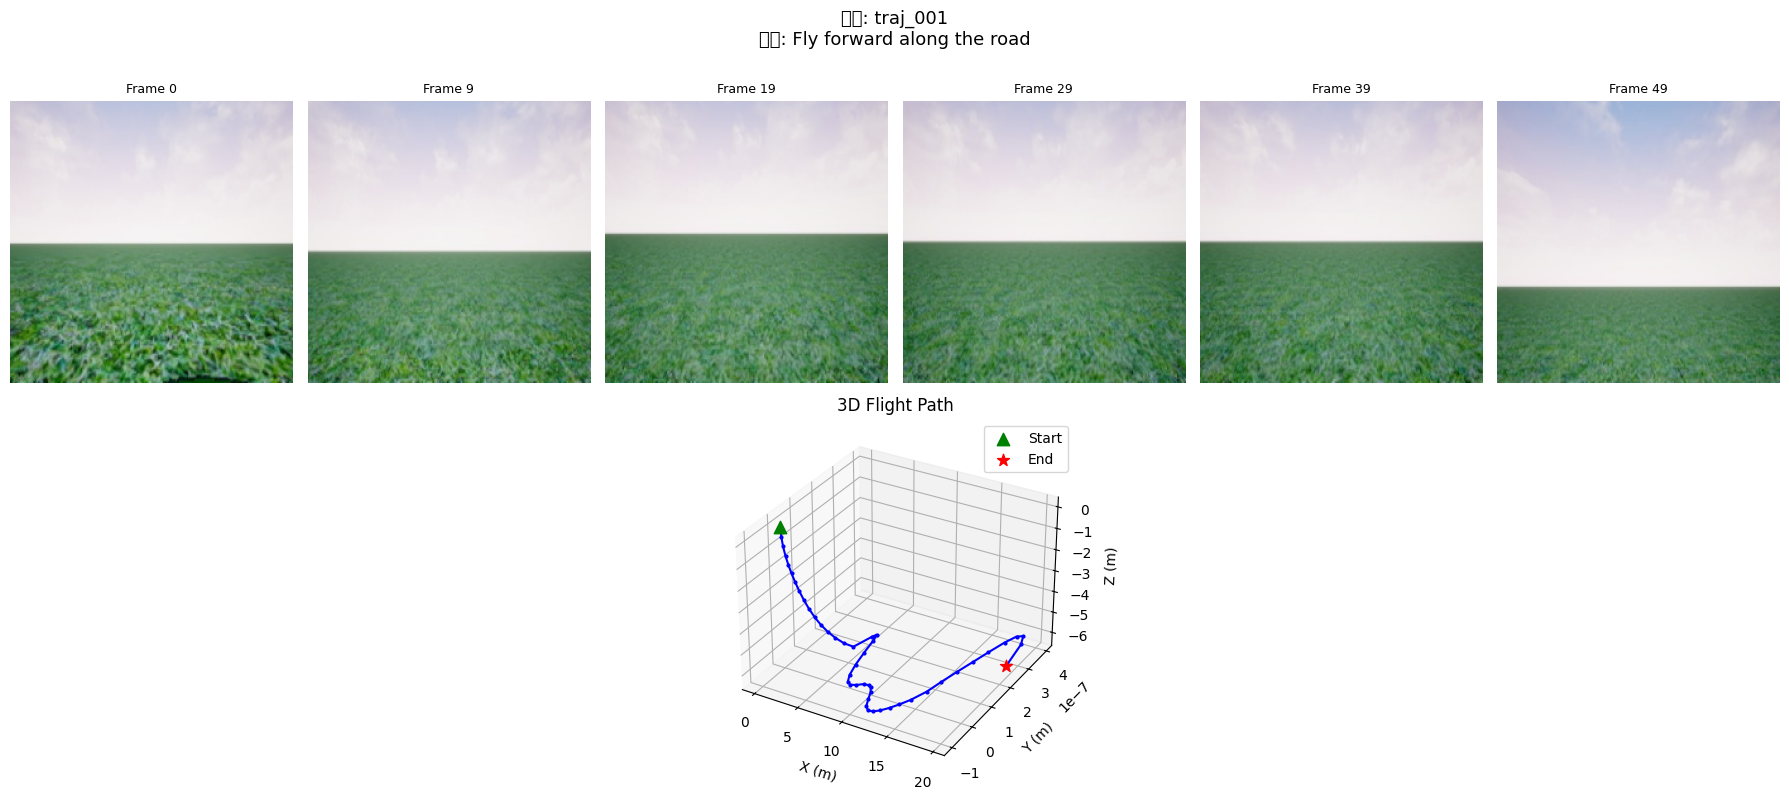

In [9]:
# 可视化：关键帧 + 3D 轨迹（和 7-1 的可视化方式一致）
sample_dir = sorted([d for d in OUTPUT_DIR.iterdir() if d.is_dir()])[0]
with open(sample_dir / "log.json") as f:
    log = json.load(f)

images = sorted(list(sample_dir.glob("*.jpg")))
n_show = min(6, len(images))
indices = np.linspace(0, len(images)-1, n_show, dtype=int)

fig = plt.figure(figsize=(18, 8))
fig.suptitle(f"轨迹: {log['id']}\n指令: {log['instruction']}", fontsize=13)

# 上排：FPV 关键帧
for col, idx in enumerate(indices):
    ax = fig.add_subplot(2, n_show, col + 1)
    ax.imshow(Image.open(images[idx]))
    ax.set_title(f"Frame {idx}", fontsize=9)
    ax.axis("off")

# 下排：3D 轨迹
ax3d = fig.add_subplot(2, 1, 2, projection='3d')
raw = np.array(log["raw_logs"])
x = raw[:, 0] - raw[0, 0]
y = raw[:, 1] - raw[0, 1]
z = raw[:, 2] - raw[0, 2]
ax3d.plot(x, y, z, 'b-o', markersize=2, linewidth=1.5)
ax3d.scatter(x[0], y[0], z[0], color='green', s=80, marker='^', label='Start')
ax3d.scatter(x[-1], y[-1], z[-1], color='red', s=80, marker='*', label='End')
ax3d.set_xlabel('X (m)'); ax3d.set_ylabel('Y (m)'); ax3d.set_zlabel('Z (m)')
ax3d.set_title('3D Flight Path')
ax3d.legend()

plt.tight_layout()
plt.show()

<ipython-input-10-a53b849d9891>:25: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-a53b849d9891>:25: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-a53b849d9891>:25: UserWarning: Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-a53b849d9891>:25: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-a53b849d9891>:25: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-a53b849d9891>:25: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-a53b849d9891>:25: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from

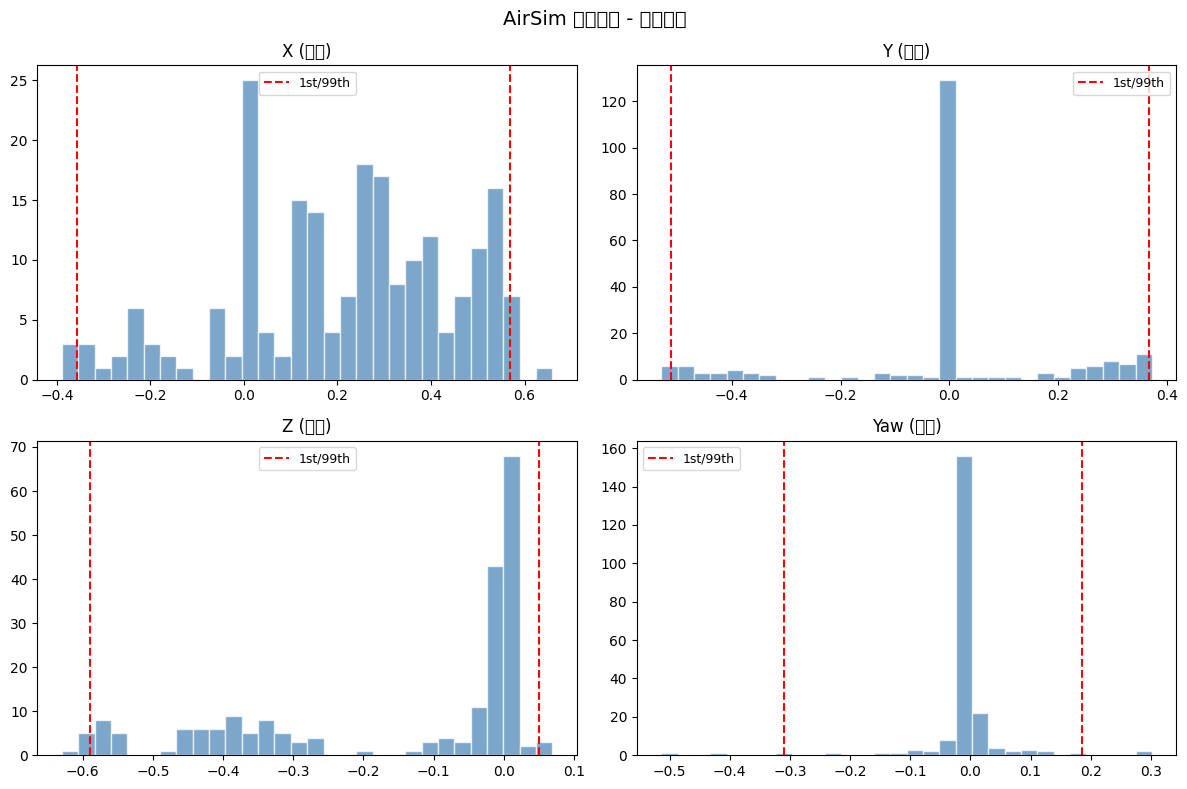

总帧数: 211
        X (前后): 1%=-0.3575  99%=+0.5688
        Y (左右): 1%=-0.5113  99%=+0.3674
        Z (上下): 1%=-0.5896  99%=+0.0497
      Yaw (偏航): 1%=-0.3093  99%=+0.1860


In [10]:
# 动作分布分析（和 7-1 的分析方式一致）
all_actions = []
for traj_dir in sorted(OUTPUT_DIR.iterdir()):
    log_path = traj_dir / "log.json"
    if not log_path.exists(): continue
    with open(log_path) as f:
        log = json.load(f)
    all_actions.extend(log["preprocessed_logs"])

all_actions = np.array(all_actions)
dim_names = ['X (前后)', 'Y (左右)', 'Z (上下)', 'Roll', 'Pitch', 'Yaw (偏航)']
used_dims = [0, 1, 2, 5]  # 训练用的 4 维（与 7-1 一致）

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, dim_idx in enumerate(axes.flatten()):
    d = used_dims[i]
    data = all_actions[:, d]
    axes.flatten()[i].hist(data, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    axes.flatten()[i].axvline(np.percentile(data, 1), color='red', linestyle='--', label='1st/99th')
    axes.flatten()[i].axvline(np.percentile(data, 99), color='red', linestyle='--')
    axes.flatten()[i].set_title(dim_names[d])
    axes.flatten()[i].legend(fontsize=9)

fig.suptitle('AirSim 采集数据 - 动作分布', fontsize=14)
plt.tight_layout()
plt.show()

print(f"总帧数: {len(all_actions)}")
for d in used_dims:
    data = all_actions[:, d]
    print(f"  {dim_names[d]:>12s}: 1%={np.percentile(data,1):+.4f}  99%={np.percentile(data,99):+.4f}")

## 0.6 与后续章节的衔接

采集的数据已与 UAV-Flow 格式完全一致，接下来：

| 步骤 | Notebook | 做什么 | 关联章节 |
|------|----------|--------|----------|
| 1. 数据采集 | **本 Notebook (7-0)** | AirSim 飞行采集 FPV + 动作 | 第1章(飞行) + 第3章(视觉) |
| 2. 数据探索 | 7-1 | 可视化、统计分析 | - |
| 3. 模型理解 | 7-2 | 理解 OpenVLA 架构 | - |
| 4. 微调训练 | 7-3 | LoRA 微调 OpenVLA | 需要 ≥24GB GPU |
| 5. 推理验证 | 7-4 | 图像+指令→动作预测 | - |
| 6. 评估分析 | 7-5 | 量化评估 | - |

**使用方法：** 将 `airsim_vln_data/` 路径替换 7-3 中的 `DATA_DIR` 即可微调：

```python
# 在 7-3 (03_finetune.ipynb) 中修改：
DATA_DIR = Path("../8-done-VLN/airsim_vln_data")  # 指向本 notebook 采集的数据
```

**增加数据量的建议：**
- 在不同 AirSim 场景中采集（House 场景、室内场景等）
- 使用自动模式让视觉模型生成多样化指令
- 变化飞行高度、速度、路径复杂度
- 建议至少 50-100 条轨迹用于微调